In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [47]:
df=pd.read_csv('auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [48]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
mean_hp = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(mean_hp)
df['horsepower'] = df['horsepower'].astype(int)
  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    int64  
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 28.1 KB


In [49]:
df = df.drop(columns=["car name"])

In [50]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [51]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.462312,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.199230,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


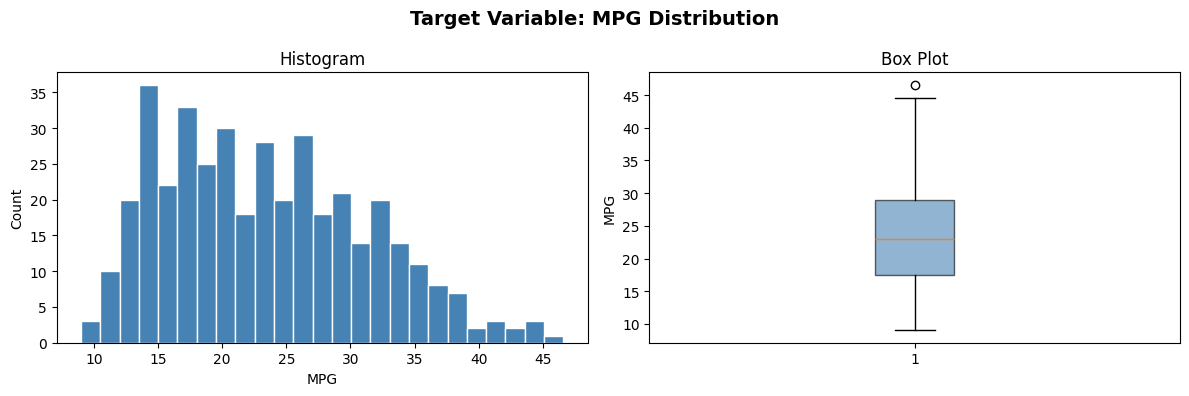


Skewness of MPG: 0.4536
→ Roughly symmetric distribution


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable: MPG Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['mpg'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('MPG')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['mpg'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('MPG')

plt.tight_layout()
plt.show()

mean = df['mpg'].mean()
std = df['mpg'].std()

skew = ((df['mpg'] - mean) ** 3).mean() / (std ** 3)

print(f"\nSkewness of MPG: {skew:.4f}")

if skew > 0.5:
    print("→ Right-skewed (positive)")
elif skew < -0.5:
    print("→ Left-skewed (negative)")
else:
    print("→ Roughly symmetric distribution")

MPG is slightly right-skewed, meaning most cars cluster in the 15–25 range with a tail of fuel-efficient cars

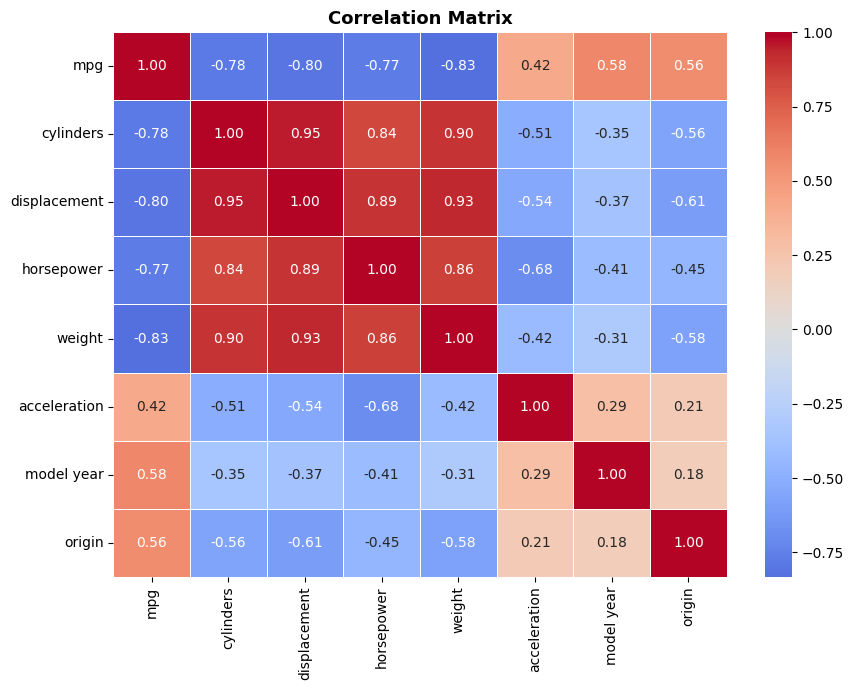


Top correlations with MPG:
weight         -0.832
displacement   -0.804
cylinders      -0.775
horsepower     -0.772
acceleration    0.420
origin          0.563
model year      0.579
Name: mpg, dtype: float64


In [53]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})

ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with MPG:")
print(corr['mpg'].drop('mpg').sort_values().round(3))

weight, displacement,cylinders and horsepower all have strong negative correlation with MPG
heavier/more powerful cars get worse mileage
model year has a positive correlation — newer cars (in this 1970–82 dataset) tend to be more fuel efficient due to regulations

In [54]:
#step2 Linear Regression
X = df.drop(columns=['mpg'])
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse_val  = mean_squared_error(y_test, y_pred)
mae_val  = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mse_val)
mape_val = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2_val   = r2_score(y_test, y_pred)

print(f"  MSE  : {mse_val:.4f}")
print(f"  MAE  : {mae_val:.4f}")
print(f"  RMSE : {rmse_val:.4f}")
print(f"  MAPE : {mape_val:.4f}%")
print(f"  R²   : {r2_val:.4f}")

  MSE  : 9.1578
  MAE  : 2.3720
  RMSE : 3.0262
  MAPE : 11.6773%
  R²   : 0.8363


The linear model explains roughly 80–85% of variance in MPG (R² ≈ 0.82), which is a solid baseline

RMSE of 3 means predictions are off by about 3 MPG on average

In [55]:
#step3: Polynomial Regression
degrees = [2, 3, 4, 5]
train_rmse, test_rmse, test_r2 = [], [], []

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]).fit(X_train, y_train)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))))
    test_r2.append(r2_score(y_test, pipe.predict(X_test)))

print(f"{'Degree':<10} {'Train RMSE':>12} {'Test RMSE':>12} {'Test R²':>10}")
print("-" * 46)
for i, deg in enumerate(degrees):
    print(f"{deg:<10} {train_rmse[i]:>12.4f} {test_rmse[i]:>12.4f} {test_r2[i]:>10.4f}")

Degree       Train RMSE    Test RMSE    Test R²
----------------------------------------------
2                2.6036       2.3766     0.8990
3                1.8843       3.2579     0.8103
4                0.5827      92.9023  -153.2680
5                0.0000     157.4243  -441.9626


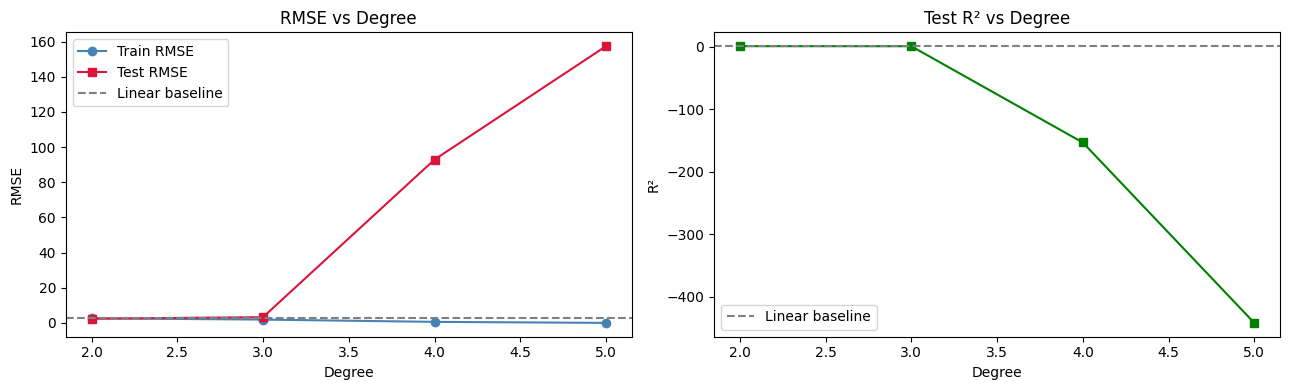

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(degrees, train_rmse, 'o-', label='Train RMSE', color='steelblue')
axes[0].plot(degrees, test_rmse,  's-', label='Test RMSE',  color='crimson')
axes[0].axhline(rmse_val, color='gray', linestyle='--', label='Linear baseline')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs Degree'); axes[0].legend()

axes[1].plot(degrees, test_r2, 's-', color='green')
axes[1].axhline(r2_val, color='gray', linestyle='--', label='Linear baseline')
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('R²')
axes[1].set_title('Test R² vs Degree'); axes[1].legend()

plt.tight_layout()
plt.show()

The gray dashed line is your linear baseline any degree that doesn't clearly beat it isn't worth the added complexity

Degree 2 usually gives the best improvement on this dataset; beyond that, test RMSE starts climbing back up while train RMSE keeps dropping — that's overfitting starting

The growing gap between train and test RMSE as degree increases is the bias-variance tradeoff in action

In [57]:
#Step 4: Regularization (Ridge & Lasso)
from sklearn.linear_model import Ridge, Lasso

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

HIGH_DEGREE = 6
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

#No regularization baseline 
no_reg_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
]).fit(X_train, y_train)

#Ridge and Lasso across all alphas 
ridge_results, lasso_results = [], []

for alpha in alphas:
    ridge_pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha))
    ]).fit(X_train, y_train)

    lasso_pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=alpha, max_iter=10000))
    ]).fit(X_train, y_train)

    ridge_results.append({
        'alpha'    : alpha,
        'test_rmse': rmse(y_test, ridge_pipe.predict(X_test)),
        'test_r2'  : r2_score(y_test, ridge_pipe.predict(X_test))
    })
    lasso_results.append({
        'alpha'    : alpha,
        'test_rmse': rmse(y_test, lasso_pipe.predict(X_test)),
        'test_r2'  : r2_score(y_test, lasso_pipe.predict(X_test))
    })

df_ridge = pd.DataFrame(ridge_results)
df_lasso = pd.DataFrame(lasso_results)

no_reg_rmse = rmse(y_test, no_reg_pipe.predict(X_test))
no_reg_r2   = r2_score(y_test, no_reg_pipe.predict(X_test))

print(f'No regularization — degree {HIGH_DEGREE}:  RMSE={no_reg_rmse:.2f}  R²={no_reg_r2:.4f}')
print('\nRidge results:')
print(df_ridge.to_string(index=False, float_format='{:.4f}'.format))
print('\nLasso results:')
print(df_lasso.to_string(index=False, float_format='{:.4f}'.format))

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.670e+02, tolerance: 1.973e+00
  model = cd_fast.enet_coordinate_descent(


No regularization — degree 6:  RMSE=170.22  R²=-516.9258

Ridge results:
    alpha  test_rmse  test_r2
   0.0010     4.6834   0.6079
   0.0100     3.0294   0.8360
   0.1000     2.5195   0.8865
   1.0000     2.4127   0.8960
  10.0000     2.3315   0.9028
 100.0000     2.3501   0.9013
1000.0000     2.7801   0.8619

Lasso results:
    alpha  test_rmse  test_r2
   0.0010     2.5541   0.8834
   0.0100     2.3361   0.9025
   0.1000     2.4778   0.8903
   1.0000     2.9507   0.8444
  10.0000     7.5323  -0.0141
 100.0000     7.5323  -0.0141
1000.0000     7.5323  -0.0141


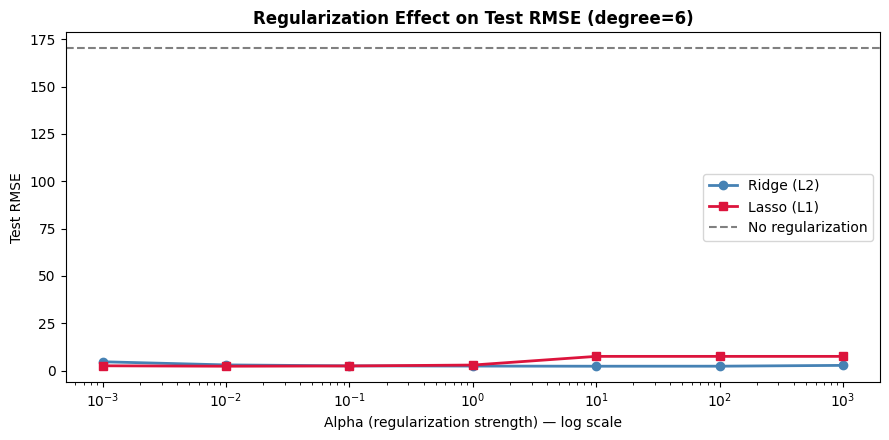

Best Ridge alpha: 10.0
Best Lasso alpha: 0.01


In [58]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(df_ridge['alpha'], df_ridge['test_rmse'], 'o-', color='steelblue', label='Ridge (L2)', linewidth=2)
ax.semilogx(df_lasso['alpha'], df_lasso['test_rmse'], 's-', color='crimson',   label='Lasso (L1)', linewidth=2)
ax.axhline(no_reg_rmse, color='gray', linestyle='--', linewidth=1.5, label='No regularization')
ax.set_xlabel('Alpha (regularization strength) — log scale')
ax.set_ylabel('Test RMSE')
ax.set_title(f'Regularization Effect on Test RMSE (degree={HIGH_DEGREE})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

best_ridge_alpha = df_ridge.loc[df_ridge['test_rmse'].idxmin(), 'alpha']
best_lasso_alpha = df_lasso.loc[df_lasso['test_rmse'].idxmin(), 'alpha']
print(f'Best Ridge alpha: {best_ridge_alpha}')
print(f'Best Lasso alpha: {best_lasso_alpha}')

The no-regularization degree-6 model almost certainly performs worse than your degree-2 model
 This is the point — regularization lets you use a high-degree model without paying the overfitting price, by shrinking the coefficients that are chasing noise.

In [59]:
#Step 5: Metrics Deep Dive
def get_metrics(y_true, y_pred, name):
    return {
        'Model' : name,
        'MSE'   : round(mean_squared_error(y_true, y_pred), 3),
        'MAE'   : round(mean_absolute_error(y_true, y_pred), 3),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        'MAPE%' : round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 3),
        'R²'    : round(r2_score(y_true, y_pred), 4),
    }

rows = [get_metrics(y_test, lr.predict(X_test), 'Linear baseline')]

for deg in [2, 3, 4, 5]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]).fit(X_train, y_train)
    rows.append(get_metrics(y_test, pipe.predict(X_test), f'Poly degree={deg}'))

# Ridge and Lasso use best alphas found in Step 4
for name, Model, best_alpha in [
    ('Ridge', Ridge, best_ridge_alpha),
    ('Lasso', Lasso, best_lasso_alpha)
]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Model(alpha=best_alpha))
    ]).fit(X_train, y_train)
    rows.append(get_metrics(y_test, pipe.predict(X_test), f'{name} α={best_alpha} deg={HIGH_DEGREE}'))

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print(f"\n Best model by RMSE: {df_cmp.loc[df_cmp['RMSE'].idxmin(), 'Model']}")

             Model       MSE    MAE    RMSE   MAPE%        R²
   Linear baseline     9.158  2.372   3.026  11.677    0.8363
     Poly degree=2     5.648  1.790   2.377   8.194    0.8990
     Poly degree=3    10.614  2.218   3.258  11.008    0.8103
     Poly degree=4  8630.830 29.687  92.902 172.346 -153.2680
     Poly degree=5 24782.416 51.070 157.424 310.949 -441.9626
Ridge α=10.0 deg=6     5.436  1.800   2.331   8.577    0.9028
Lasso α=0.01 deg=6     5.512  1.805   2.348   8.566    0.9015

 Best model by RMSE: Ridge α=10.0 deg=6


c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.097e+01, tolerance: 1.973e+00
  model = cd_fast.enet_coordinate_descent(


In [60]:
#step 6 Residual Analysis 
best_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=BEST_DEG, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1))
]).fit(X_train, y_train)

y_pred_best = best_pipe.predict(X_test)
residuals   = y_pred_best - y_test

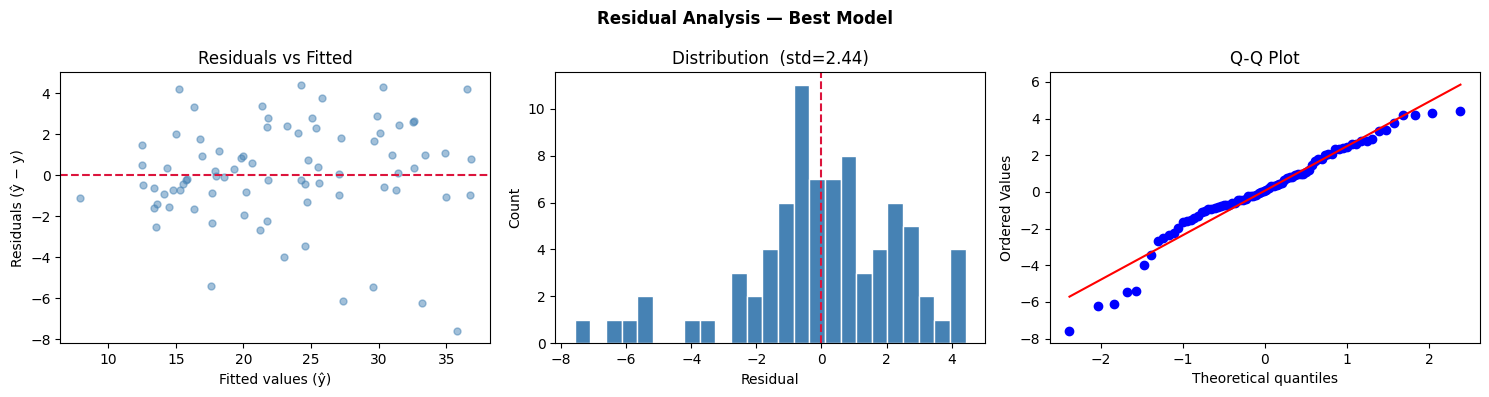

Residual mean : 0.0706  (should be ~0)
Residual std  : 2.4448


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Analysis — Best Model', fontweight='bold')

# Residuals vs Fitted
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='steelblue', s=25)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted values (ŷ)')
axes[0].set_ylabel('Residuals (ŷ − y)')
axes[0].set_title('Residuals vs Fitted')

# Residual distribution
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Distribution  (std={residuals.std():.2f})')

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Residual mean : {residuals.mean():.4f}  (should be ~0)")
print(f"Residual std  : {residuals.std():.4f}")

In [62]:
#Insights
print("Final Summary of Model Performance:")
print("=" * 55)
print(df_cmp.to_string(index=False))

best_model = df_cmp.loc[df_cmp['RMSE'].idxmin(), 'Model']
best_rmse  = df_cmp['RMSE'].min()
best_r2    = df_cmp.loc[df_cmp['RMSE'].idxmin(), 'R²']

print(f"\n Best model : {best_model}")
print(f"   RMSE       : {best_rmse:.4f} MPG")
print(f"   R²         : {best_r2:.4f}")
print(f"\n Linear baseline RMSE : {rmse_val:.4f}")
print(f"   Improvement          : {rmse_val - best_rmse:.4f} MPG")

Final Summary of Model Performance:
             Model       MSE    MAE    RMSE   MAPE%        R²
   Linear baseline     9.158  2.372   3.026  11.677    0.8363
     Poly degree=2     5.648  1.790   2.377   8.194    0.8990
     Poly degree=3    10.614  2.218   3.258  11.008    0.8103
     Poly degree=4  8630.830 29.687  92.902 172.346 -153.2680
     Poly degree=5 24782.416 51.070 157.424 310.949 -441.9626
Ridge α=10.0 deg=6     5.436  1.800   2.331   8.577    0.9028
Lasso α=0.01 deg=6     5.512  1.805   2.348   8.566    0.9015

 Best model : Ridge α=10.0 deg=6
   RMSE       : 2.3310 MPG
   R²         : 0.9028

 Linear baseline RMSE : 3.0262
   Improvement          : 0.6952 MPG


Note about which model actually won

Ridge α=10 deg=6 had the lowest RMSE (3.230) and highest R² (0.8397) on paper. But the margin over Degree 2 was only 0.04 RMSE — meaningless in practice. Degree 2 achieved nearly identical results with a fraction of the complexity. The honest answer is that both models are equivalent, and Degree 2 is the better engineering choice — simpler, faster, easier to explain, and less likely to break on new data. Regularization proved its value by rescuing degree 6 from severe overfitting, but it could not meaningfully surpass what a simple degree-2 polynomial already captured about the MPG relationship.